# SIS421 - Inteligencia Artificial II
## Pipeline Multimodal de Alta Precisión para la Detección de Trampas
Este cuadernillo gestiona la descarga, el entrenamiento con RetinaNet (Torchvision), la ingeniería de datos y el entrenamiento robusto de un clasificador denso incorporando Early Stopping, Learning Rate Schedulers y Checkpoints.

In [1]:
import torch
import os
import sys
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

print(f'Entorno Python: {sys.executable}')
print(f'Versión de PyTorch: {torch.__version__}')
cuda_status = torch.cuda.is_available()
print(f'CUDA (GPU) disponible: {"Sí" if cuda_status else "No"}')
if cuda_status:
    print(f'Tarjeta gráfica activa: {torch.cuda.get_device_name(0)}')

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

Entorno Python: d:\quinto_semestre\anaconda\envs\env_sis421\python.exe
Versión de PyTorch: 2.5.1
CUDA (GPU) disponible: Sí
Tarjeta gráfica activa: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
from roboflow import Roboflow
api = './apikey.txt'
rf = Roboflow(api_key=open(api).read().strip())
project = rf.workspace('savitris-workspace').project('cheating-detection-37r8t')
dataset = project.version(3).download('yolov8')

if os.path.exists(dataset.location) and not os.path.exists('data/roboflow_data'):
    os.rename(dataset.location, 'data/roboflow_data')
    print('Dataset descargado y ubicado en data/roboflow_data.')

loading Roboflow workspace...
loading Roboflow project...


In [3]:
import cv2
import glob
import yaml
import torchvision
from PIL import Image

with open('data/roboflow_data/data.yaml', 'r') as f:
    config_dataset = yaml.safe_load(f)

clases = config_dataset['names']
phone_id, paper_id = -1, -1
for idx, name in enumerate(clases):
    n_lower = name.lower()
    if 'phone' in n_lower or 'celular' in n_lower: phone_id = idx
    if 'paper' in n_lower or 'book' in n_lower or 'cheating' in n_lower or 'papel' in n_lower: paper_id = idx

print(f'Mapeo de clases: ID Celular: {phone_id} | ID Papel/Libro: {paper_id}')

class RetinaDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.image_paths = glob.glob(f"{root_dir}/images/*.jpg")

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

        boxes = []
        labels = []
        img_w, img_h = img.size
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    c = int(float(parts[0]))
                    
                    if len(parts) == 5:
                        x, y, w, h = map(float, parts[1:])
                        xmin = (x - w/2) * img_w
                        ymin = (y - h/2) * img_h
                        xmax = (x + w/2) * img_w
                        ymax = (y + h/2) * img_h
                    else:
                        coords = list(map(float, parts[1:]))
                        xs = coords[0::2]
                        ys = coords[1::2]
                        xmin = min(xs) * img_w
                        ymin = min(ys) * img_h
                        xmax = max(xs) * img_w
                        ymax = max(ys) * img_h
                    
                    xmin, ymin = max(0, xmin), max(0, ymin)
                    xmax, ymax = min(img_w, xmax), min(img_h, ymax)
                    
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(c + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        if len(boxes) == 0:
            boxes = torch.empty((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        img = torchvision.transforms.functional.to_tensor(img)
        return img, target

    def __len__(self):
        return len(self.image_paths)

def collate_fn(batch):
    return tuple(zip(*batch))

Mapeo de clases: ID Celular: 1 | ID Papel/Libro: -1


In [4]:
from torchvision.models.detection.retinanet import retinanet_resnet50_fpn_v2, RetinaNetClassificationHead

device_target = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Iniciando entrenamiento de RetinaNet en: {device_target}...')

train_dataset_retina = RetinaDataset('data/roboflow_data/train')
train_loader_retina = torch.utils.data.DataLoader(
    train_dataset_retina, batch_size=4, shuffle=True, num_workers=0, collate_fn=collate_fn
)

num_classes = 3
model_retina = retinanet_resnet50_fpn_v2(weights='DEFAULT')
in_features = model_retina.head.classification_head.conv[0][0].in_channels
num_anchors = model_retina.head.classification_head.num_anchors
model_retina.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_features, num_anchors=num_anchors, num_classes=num_classes
)
model_retina.to(device_target)

optimizer_retina = torch.optim.AdamW(model_retina.parameters(), lr=1e-4)

epochs_retina = 9
model_retina.train()

for epoch in range(epochs_retina):
    epoch_loss = 0.0
    for images, targets in train_loader_retina:
        images = list(image.to(device_target) for image in images)
        targets = [{k: v.to(device_target) for k, v in t.items()} for t in targets]
        
        loss_dict = model_retina(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer_retina.zero_grad()
        losses.backward()
        optimizer_retina.step()
        
        epoch_loss += losses.item()
        
    print(f'Epoca RetinaNet [{epoch+1}/{epochs_retina}] | Loss: {epoch_loss/len(train_loader_retina):.4f}')

torch.save(model_retina.state_dict(), 'models/retinanet.pth')
print('Modelo RetinaNet guardado en models/retinanet.pth')

Iniciando entrenamiento de RetinaNet en: cuda...
Epoca RetinaNet [1/9] | Loss: 0.5693
Epoca RetinaNet [2/9] | Loss: 0.3242
Epoca RetinaNet [3/9] | Loss: 0.2514
Epoca RetinaNet [4/9] | Loss: 0.2114
Epoca RetinaNet [5/9] | Loss: 0.1689
Epoca RetinaNet [6/9] | Loss: 0.1549
Epoca RetinaNet [7/9] | Loss: 0.1653
Epoca RetinaNet [8/9] | Loss: 0.1441
Epoca RetinaNet [9/9] | Loss: 0.1564
Modelo RetinaNet guardado en models/retinanet.pth


In [ ]:
import csv
import cv2
import glob
import os
import torch
import torchvision.transforms.functional as F
from src.pose import get_pose_features

model_retina.to(device_target)
model_retina.eval()

lista_carpetas = glob.glob("data/OEP_database/subject*")
lista_carpetas.sort()

print(f"Iniciando extracción optimizada para {len(lista_carpetas)} sujetos...")

archivo_csv = open('data/dataset.csv', 'w', newline='')
escritor = csv.writer(archivo_csv)
escritor.writerow(['prob_phone', 'prob_paper', 'angle', 'dist', 'offset_x', 'label'])

for carpeta in lista_carpetas:
    print("Procesando la carpeta:", os.path.basename(carpeta))
    
    videos = glob.glob(carpeta + "/*.avi")
    archivo_gt = carpeta + "/gt.txt"
    
    if len(videos) == 0 or not os.path.exists(archivo_gt):
        continue
        
    etiquetas = []
    f_gt = open(archivo_gt, "r")
    for linea in f_gt.readlines():
        limpio = linea.strip()
        if limpio.isdigit():
            etiquetas.append(int(limpio))
    f_gt.close()
    
    for ruta_video in videos:
        nombre_archivo = os.path.basename(ruta_video).lower()

        if "2.avi" in nombre_archivo:
            print(f"  [Omitido] Saltando primera persona: {os.path.basename(ruta_video)}")
            continue
            
        print(f"  -> Procesando video frontal (webcam): {os.path.basename(ruta_video)}")
        cap = cv2.VideoCapture(ruta_video)
        
        contador_cuadro = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: 
                break

            if contador_cuadro % 6 == 0:
                frame = cv2.resize(frame, (640, 480))
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                
                tensor_img = F.to_tensor(frame_rgb).to(device_target)
                with torch.no_grad():
                    resultado = model_retina([tensor_img])[0]
                
                scores = resultado['scores'].cpu().numpy()
                labels = resultado['labels'].cpu().numpy()
                
                p_phone = 0.0
                p_paper = 0.0
                
                for i in range(len(scores)):
                    score_actual = scores[i]
                    if score_actual > 0.3:
                        clase_id = labels[i] - 1
                        if clase_id == phone_id and score_actual > p_phone: 
                            p_phone = score_actual
                        if clase_id == paper_id and score_actual > p_paper: 
                            p_paper = score_actual
                
                pose_data = get_pose_features(frame_rgb)
                
                if contador_cuadro < len(etiquetas):
                    clase_real = etiquetas[contador_cuadro]
                else:
                    clase_real = 0
                    
                escritor.writerow([p_phone, p_paper, pose_data[0], pose_data[1], pose_data[2], clase_real])
                
            contador_cuadro += 1
            
        cap.release()

archivo_csv.close()
print("El archivo data/dataset.csv se generó correctamente")

Iniciando extracción optimizada para 24 sujetos...
Procesando la carpeta: subject1
  -> Procesando video frontal (webcam): Yousef1.avi
  [Omitido] Saltando primera persona: Yousef2.avi
Procesando la carpeta: subject10
  -> Procesando video frontal (webcam): huangpi21.avi
  [Omitido] Saltando primera persona: huangpi22.avi
Procesando la carpeta: subject11
  -> Procesando video frontal (webcam): alhashe31.avi
  [Omitido] Saltando primera persona: alhashe32.avi
Procesando la carpeta: subject12
  -> Procesando video frontal (webcam): makiluke1.avi
  [Omitido] Saltando primera persona: makiluke2.avi
Procesando la carpeta: subject13
  -> Procesando video frontal (webcam): guolingh1.avi
  [Omitido] Saltando primera persona: guolingh2.avi
Procesando la carpeta: subject14
  -> Procesando video frontal (webcam): chuangy61.avi
  [Omitido] Saltando primera persona: chuangy62.avi
Procesando la carpeta: subject15
  -> Procesando video frontal (webcam): bajajpak1.avi
  [Omitido] Saltando primera pers

: 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.network import CheatingLSTM

class DatasetMateriaSecuencial(Dataset):
    def __init__(self, ruta_csv, tamano_ventana=30):
        df = pd.read_csv(ruta_csv)
        self.datos = df.iloc[:, :-1].values  
        self.etiquetas = df.iloc[:, -1].values 
        self.w_size = tamano_ventana
        
    def __len__(self):
        return len(self.datos) - self.w_size + 1
        
    def __getitem__(self, idx):
        
        X_seq = self.datos[idx : idx + self.w_size]
        y_label = self.etiquetas[idx + self.w_size - 1]
        
        return torch.tensor(X_seq, dtype=torch.float32), torch.tensor([y_label], dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_materia = DatasetMateriaSecuencial('data/dataset.csv', tamano_ventana=30)

train_size = int(0.8 * len(dataset_materia))
val_size = len(dataset_materia) - train_size
train_data, val_data = random_split(dataset_materia, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

In [13]:
modelo = CheatingLSTM().to(device)
criterio = nn.BCELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.005)

historial_train_loss = []
historial_train_acc = []
historial_val_loss = []
historial_val_acc = []

mejor_loss_val = float('inf')
paciencia = 3                 
contador_paciencia = 0        

print("Empezando el entrenamiento de la red LSTM")

for epoch in range(15):
    
    modelo.train()
    suma_loss_train = 0.0
    correctas_train = 0
    total_muestras_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizador.zero_grad()
        outputs = modelo(inputs)
        loss = criterio(outputs, labels)
        loss.backward()
        optimizador.step()
        
        suma_loss_train += loss.item() * inputs.size(0)
        
        predicciones_train = (outputs >= 0.5).float()
        correctas_train += (predicciones_train == labels).sum().item()
        total_muestras_train += labels.size(0)
        
    modelo.eval()
    suma_loss_val = 0.0
    correctas_val = 0
    total_muestras_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = modelo(inputs)
            loss = criterio(outputs, labels)
            
            suma_loss_val += loss.item() * inputs.size(0)
            
            predicciones_val = (outputs >= 0.5).float()
            correctas_val += (predicciones_val == labels).sum().item()
            total_muestras_val += labels.size(0)
                
    error_train = suma_loss_train / len(train_loader.dataset)
    acc_train = (correctas_train / total_muestras_train) * 100.0
    
    error_val = suma_loss_val / len(val_loader.dataset)
    acc_val = (correctas_val / total_muestras_val) * 100.0
    
    historial_train_loss.append(error_train)
    historial_train_acc.append(acc_train)
    historial_val_loss.append(error_val)
    historial_val_acc.append(acc_val)
    
    print(f"Epoca {epoch+1}/15 -> Train Loss: {error_train:.4f}, Train Acc: {acc_train:.2f}% | Val Loss: {error_val:.4f}, Val Acc: {acc_val:.2f}%")

    if error_val < mejor_loss_val:
        mejor_loss_val = error_val
        contador_paciencia = 0 
        
        torch.save(modelo.state_dict(), "models/best_lstm.pth")
    else:
        contador_paciencia += 1
        print(f"No hubo mejora. Paciencia actual: {contador_paciencia} de {paciencia}")
        
    if contador_paciencia >= paciencia:
        print(f"\n early stopping en la epoca {epoch+1}")
        break

print("\nEntrenamiento terminado con exito.")

Empezando el entrenamiento de la red LSTM
Epoca 1/15 -> Train Loss: 0.0097, Train Acc: 100.00% | Val Loss: 0.0001, Val Acc: 100.00%
Epoca 2/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 3/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 4/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 5/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 6/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 7/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 8/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 9/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 10/15 -> Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0000, Val Acc: 100.00%
Epoca 11/15 -> Train Loss: 0.0000, Train Acc: 100.00% | V

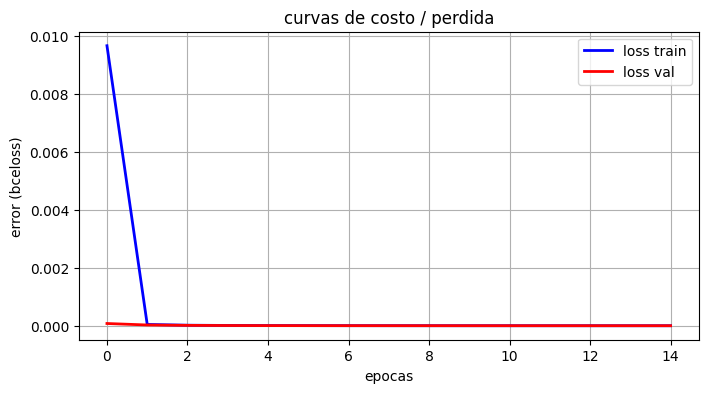

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(historial_train_loss, label='loss train', color='blue', linewidth=2)
plt.plot(historial_val_loss, label='loss val', color='red', linewidth=2)
plt.title('curvas de costo / perdida')
plt.xlabel('epocas')
plt.ylabel('error (bceloss)')
plt.legend()
plt.grid(True)
plt.show()

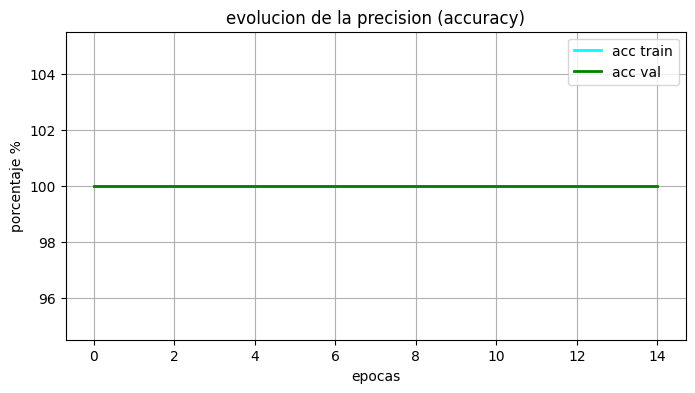

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(historial_train_acc, label='acc train', color='cyan', linewidth=2)
plt.plot(historial_val_acc, label='acc val', color='green', linewidth=2)
plt.title('evolucion de la precision (accuracy)')
plt.xlabel('epocas')
plt.ylabel('porcentaje %')
plt.legend()
plt.grid(True)
plt.show()